# Part B — Baseline: Ukraine Inflation Counterfactual

This notebook builds a **baseline counterfactual** using the Ciccarelli & Mojon (2010) common factor approach.
The baseline uses the Euro Area cross-sectional mean as the counterfactual path — i.e., what Ukraine's inflation would have looked like had it tracked the EA common inflation component.

The PCA is kept to validate the single-factor hypothesis (84.7% of EA variance explained by PC1). The regression step is dropped because Ukraine's structural heterogeneity makes a stable OLS loading impossible to estimate — this is itself an empirical finding that motivates the SVAR.

**Structure:**
1. Data loading
2. Descriptive visualisation with regime shading (Part A)
3. Stationarity tests
4. PCA — validation of the common factor hypothesis
5. Baseline counterfactual (EA mean)
6. Limitations → roadmap to SVAR

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

cwd = Path.cwd()
DATA_PROCESSED = cwd.parent / "data" / "data_processed"
OUTPUTS = cwd.parent.parent / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

## 1. Data loading

In [2]:
df = pd.read_csv(
    DATA_PROCESSED / "inflation_panel.csv",
    parse_dates=["date"],
    index_col="date"
)

EA_COUNTRIES = [c for c in df.columns if c != "UKR"]
ea_mean = df[EA_COUNTRIES].mean(axis=1)

print(f"Shape: {df.shape} | {df.index.min().date()} to {df.index.max().date()}")
print(f"EA countries: {EA_COUNTRIES}")
print()
df.describe().T[["mean", "std", "min", "max"]].round(2)

Shape: (240, 12) | 2006-01-01 to 2025-12-01
EA countries: ['AT', 'BE', 'DE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'NL', 'PT']



,mean,std,min,max
AT,2.68,2.19,-0.4,11.60
BE,2.53,2.37,-1.7,13.10
DE,2.22,2.13,-0.7,11.60
ES,2.14,2.22,-1.5,10.70
FI,2.01,1.81,-0.7,9.10
FR,1.85,1.65,-0.8,7.30
GR,1.93,2.71,-2.9,12.10
IE,1.48,2.38,-2.9,9.60
IT,2.02,2.34,-1.0,12.60
NL,2.37,2.63,-1.0,17.10


## 2. Descriptive visualisation

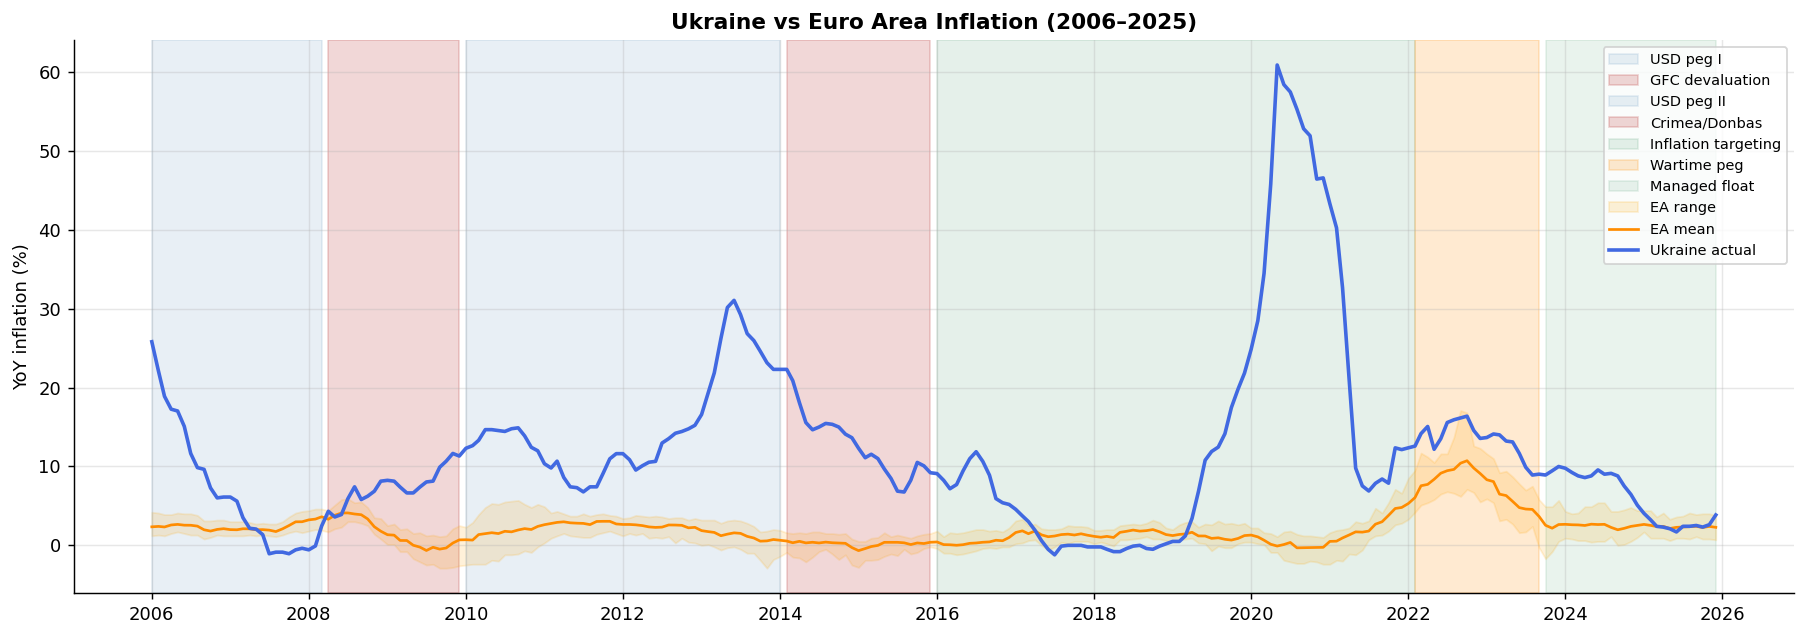

In [3]:
# Regime periods from Part A chronology
REGIMES = [
    ("2006-01", "2008-03", "USD peg I",          "steelblue",  0.12),
    ("2008-04", "2009-12", "GFC devaluation",     "firebrick",  0.18),
    ("2010-01", "2014-01", "USD peg II",          "steelblue",  0.12),
    ("2014-02", "2015-12", "Crimea/Donbas",       "firebrick",  0.18),
    ("2016-01", "2022-02", "Inflation targeting", "seagreen",   0.12),
    ("2022-02", "2023-09", "Wartime peg",         "darkorange", 0.18),
    ("2023-10", "2025-12", "Managed float",       "seagreen",   0.10),
]

fig, ax = plt.subplots(figsize=(14, 5))

for start, end, label, color, alpha in REGIMES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha, label=label)

ax.fill_between(df.index, df[EA_COUNTRIES].min(axis=1), df[EA_COUNTRIES].max(axis=1),
                color="orange", alpha=0.15, label="EA range")
ax.plot(df.index, ea_mean, color="darkorange", lw=1.5, label="EA mean")
ax.plot(df.index, df["UKR"], color="royalblue", lw=2, label="Ukraine actual")

handles, labels = ax.get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if l not in seen and not seen.add(l)]
ax.legend(*zip(*unique), fontsize=8, loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_ylabel("YoY inflation (%)")
ax.set_title("Ukraine vs Euro Area Inflation (2006–2025)", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "fig1_raw_series.png", dpi=150)
plt.show()

## 3. Stationarity tests (ADF + KPSS)

In [4]:
results = []
for col in df.columns:
    s = df[col].dropna()
    adf_p  = adfuller(s, autolag="AIC")[1]
    kpss_p = kpss(s, regression="ct", nlags="auto")[1]
    results.append({
        "Country":        col,
        "ADF p-val":      round(adf_p, 3),
        "ADF reject H0":  "Yes" if adf_p  < 0.05 else "No",
        "KPSS p-val":     round(kpss_p, 3),
        "KPSS reject H0": "Yes" if kpss_p < 0.05 else "No",
        "Verdict":        "Stationary" if (adf_p < 0.05 and kpss_p >= 0.05) else "Ambiguous"
    })

stat_df = pd.DataFrame(results).set_index("Country")
print(stat_df.to_string())
print()
print("Note: 'Ambiguous' is expected for inflation over 20 years with structural breaks.")
print("Standard practice (Ciccarelli-Mojon 2010) is to work in levels for YoY inflation.")

         ADF p-val ADF reject H0  KPSS p-val KPSS reject H0     Verdict
Country                                                                
AT           0.119            No       0.043            Yes   Ambiguous
BE           0.118            No       0.075             No   Ambiguous
DE           0.043           Yes       0.045            Yes   Ambiguous
ES           0.175            No       0.010            Yes   Ambiguous
FI           0.070            No       0.067             No   Ambiguous
FR           0.243            No       0.035            Yes   Ambiguous
GR           0.250            No       0.010            Yes   Ambiguous
IE           0.078            No       0.024            Yes   Ambiguous
IT           0.102            No       0.053             No   Ambiguous
NL           0.265            No       0.057             No   Ambiguous
PT           0.122            No       0.033            Yes   Ambiguous
UKR          0.044           Yes       0.100             No  Sta

C:\Users\hlarbi\AppData\Local\Temp\ipykernel_8592\1425603067.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="ct", nlags="auto")[1]
C:\Users\hlarbi\AppData\Local\Temp\ipykernel_8592\1425603067.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="ct", nlags="auto")[1]
C:\Users\hlarbi\AppData\Local\Temp\ipykernel_8592\1425603067.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression="ct", nlags="auto")[1]


## 4. PCA — validating the single common factor hypothesis

We run PCA on the 11 EA countries (Ukraine excluded) to verify that a single common factor drives most EA inflation variation. This validates the Ciccarelli-Mojon hypothesis. The factor itself is not used in the regression — see Section 5 for why.

PC1 explains 84.7% of EA inflation variance — single factor hypothesis validated.
PC1 + PC2: 89.4%


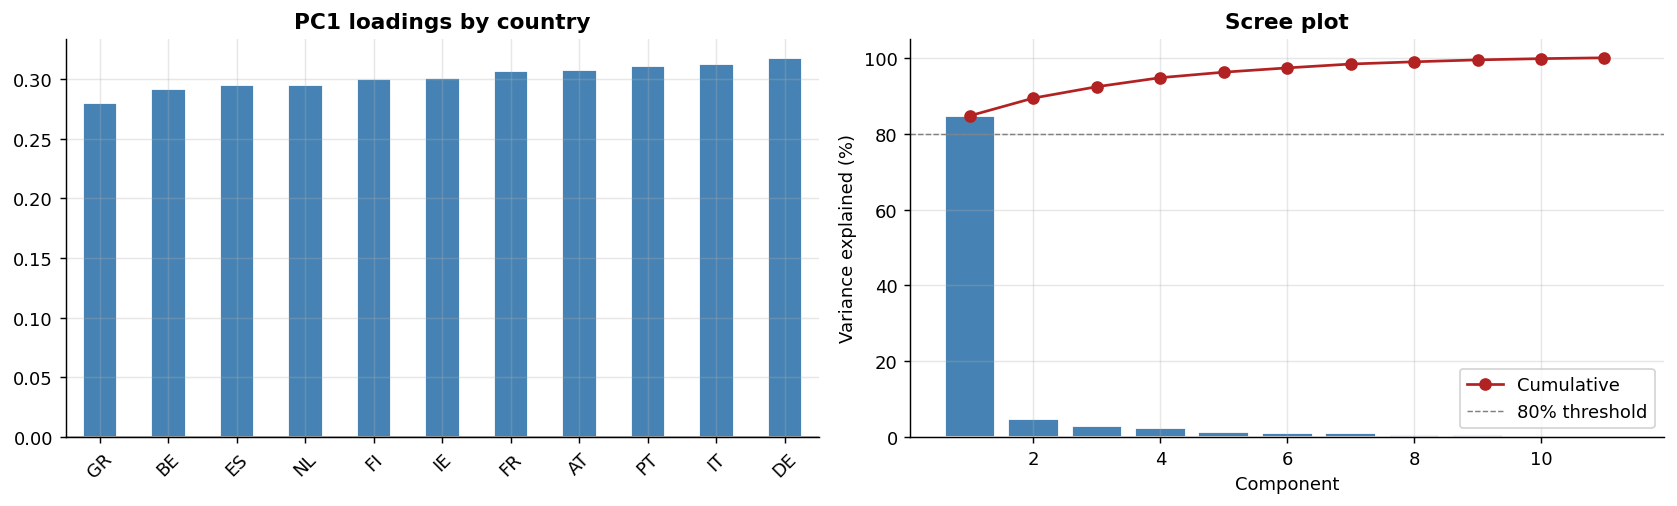

In [5]:
euro_df     = df[EA_COUNTRIES].copy()
euro_scaled = StandardScaler().fit_transform(euro_df)

pca      = PCA(n_components=len(EA_COUNTRIES))
pca.fit(euro_scaled)
explained = pca.explained_variance_ratio_

print(f"PC1 explains {explained[0]:.1%} of EA inflation variance — single factor hypothesis validated.")
print(f"PC1 + PC2: {explained[0]+explained[1]:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pd.Series(pca.components_[0], index=EA_COUNTRIES).sort_values().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("PC1 loadings by country", fontweight="bold")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(range(1, len(explained)+1), explained*100, color="steelblue", edgecolor="white")
axes[1].plot(range(1, len(explained)+1), np.cumsum(explained)*100,
             "o-", color="firebrick", label="Cumulative")
axes[1].axhline(80, color="gray", ls="--", lw=0.8, label="80% threshold")
axes[1].set_title("Scree plot", fontweight="bold")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Variance explained (%)")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "fig2_pca_diagnostics.png", dpi=150)
plt.show()

## 5. Baseline counterfactual

The counterfactual is the EA cross-sectional mean inflation. This represents the inflation path Ukraine would have followed had it been an average EA member — subject to the same ECB monetary policy, same common shocks, same nominal anchor.

**Why not use OLS with the PCA factor?**
Estimating a stable loading λ for Ukraine on the EA factor is not feasible: during the peg periods, Ukraine co-moves positively with EA; during the crisis episodes, it diverges sharply. The relationship is structurally unstable. Any λ estimated over a subsample gives implausible out-of-sample predictions (negative counterfactual inflation during 2022). This instability is itself economically meaningful — it shows that Ukraine was too structurally heterogeneous for a simple linear projection. The SVAR addresses this by identifying supply vs demand shocks explicitly.

In [6]:
data = df[["UKR"]].copy()
data["counterfactual"] = ea_mean
data["gap"] = data["UKR"] - data["counterfactual"]

# Period-by-period summary
episodes = [
    ("2006-01", "2008-03", "USD peg I"),
    ("2008-04", "2009-12", "GFC 2008-09"),
    ("2010-01", "2014-01", "USD peg II"),
    ("2014-02", "2015-12", "Crimea/Donbas"),
    ("2016-01", "2022-02", "Inflation targeting"),
    ("2022-02", "2023-09", "Wartime"),
    ("2023-10", "2025-12", "Managed float"),
]

print(f"{'Period':<25} {'Actual':>8} {'CF (EA mean)':>13} {'Gap':>8}")
print("-" * 58)
for s, e, label in episodes:
    m = (data.index >= s) & (data.index <= e)
    if m.sum():
        a = data.loc[m, "UKR"].mean()
        c = data.loc[m, "counterfactual"].mean()
        print(f"{label:<25} {a:>7.1f}%  {c:>12.1f}%  {a-c:>+7.1f}pp")

Period                      Actual  CF (EA mean)      Gap
----------------------------------------------------------
USD peg I                     6.8%           2.4%     +4.5pp
GFC 2008-09                   7.4%           1.6%     +5.8pp
USD peg II                   15.1%           2.0%    +13.1pp
Crimea/Donbas                12.9%           0.2%    +12.7pp
Inflation targeting          13.9%           1.3%    +12.6pp
Wartime                      13.4%           7.5%     +5.8pp
Managed float                 6.0%           2.4%     +3.5pp


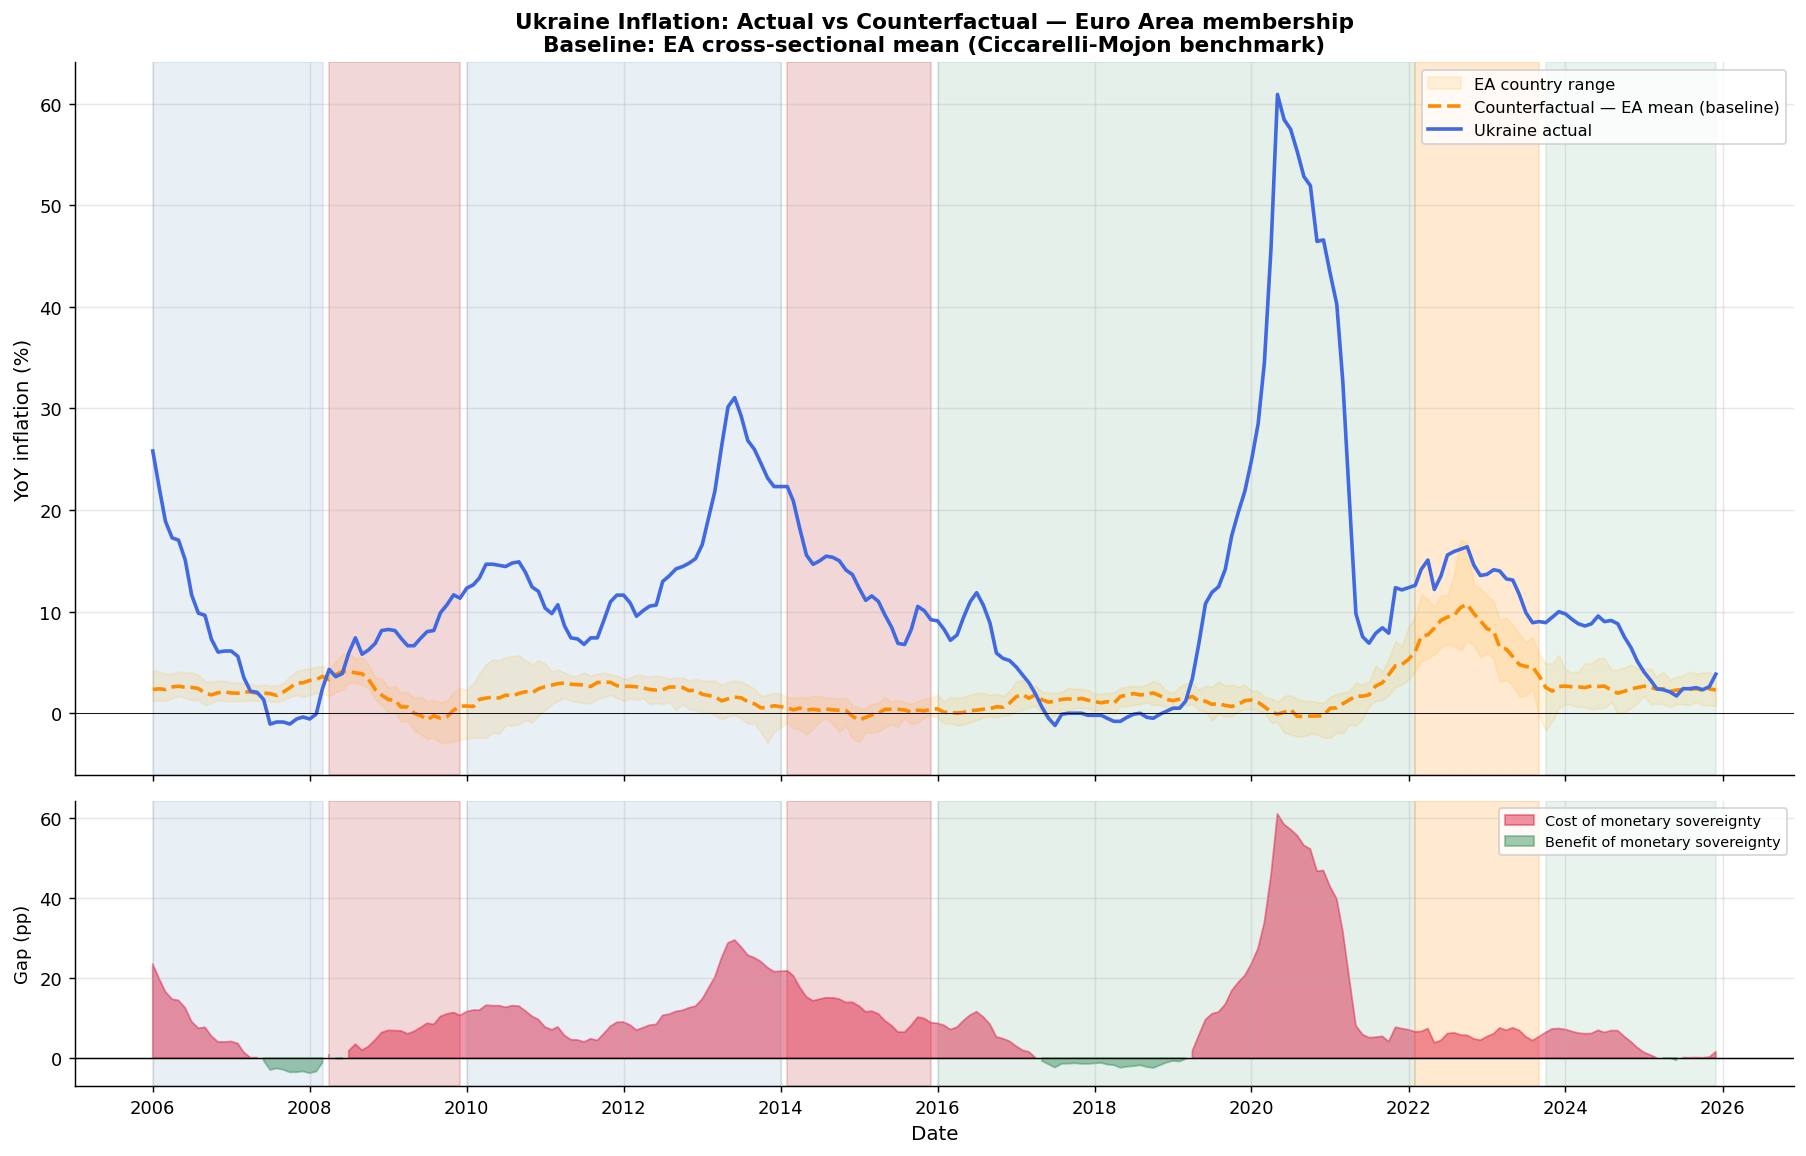

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={"height_ratios": [2.5, 1]})
ax, ax2 = axes

for start, end, _, color, alpha in REGIMES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)

ax.fill_between(df.index, df[EA_COUNTRIES].min(axis=1), df[EA_COUNTRIES].max(axis=1),
                color="orange", alpha=0.12, label="EA country range")
ax.plot(data.index, data["counterfactual"], color="darkorange", lw=2, ls="--",
        label="Counterfactual — EA mean (baseline)")
ax.plot(data.index, data["UKR"], color="royalblue", lw=2,
        label="Ukraine actual")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("YoY inflation (%)", fontsize=11)
ax.set_title(
    "Ukraine Inflation: Actual vs Counterfactual — Euro Area membership\n"
    "Baseline: EA cross-sectional mean (Ciccarelli-Mojon benchmark)",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper right")

ax2.fill_between(data.index, data["gap"], 0,
                 where=data["gap"] > 0,
                 color="crimson", alpha=0.45, label="Cost of monetary sovereignty")
ax2.fill_between(data.index, data["gap"], 0,
                 where=data["gap"] < 0,
                 color="seagreen", alpha=0.45, label="Benefit of monetary sovereignty")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Gap (pp)", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=8, loc="upper right")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(OUTPUTS / "fig3_counterfactual_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Limitations and roadmap to SVAR

**What this baseline does:** it provides an interpretable, economically grounded first-pass counterfactual. The EA mean is the natural benchmark — it is what an "average" EA member experiences under ECB monetary policy and common shocks.

**What it cannot do:**

- **No structural identification.** The EA mean includes both supply shocks (energy, global commodities) and demand shocks (ECB policy). Under EA membership, Ukraine's supply shocks — energy dependence on Russia, agricultural exports, geopolitical exposure — would still have been its own. Only demand shocks would have been replaced by the ECB's. The baseline makes no distinction between the two.

- **No treatment heterogeneity.** From Part A: during the USD peg periods, Ukraine had no independent monetary policy — EA membership would have changed little. During 2014-15 and 2022, Ukraine exercised full monetary sovereignty via devaluation — EA membership would have changed everything. The baseline applies a constant counterfactual regardless of the monetary regime.

- **No dynamics.** The baseline is static. It does not show how long the counterfactual gap would have persisted after each shock.

**→ Next step:** SVAR with Blanchard-Quah identification (permanent shocks = supply, transitory = demand). This separates the two channels and allows regime-specific treatment weighting consistent with Part A.

In [8]:
data.to_csv(DATA_PROCESSED / "baseline_counterfactual.csv")
print("Saved: baseline_counterfactual.csv")
print(f"Columns: {list(data.columns)}")
print(f"Shape: {data.shape}")

Saved: baseline_counterfactual.csv
Columns: ['UKR', 'counterfactual', 'gap']
Shape: (240, 3)
